# References

## Main reference

* https://towardsdatascience.com/k-means-clustering-chardonnay-reviews-using-scikit-learn-nltk-9df3c59527f3

## Other eferences

* https://lamfo-unb.github.io/2019/09/02/cluster_texto/
* https://www.datacamp.com/community/tutorials/pandas-tutorial-dataframe-python
* https://geodacenter.github.io/workbook/7c_clusters_3/lab7c.html
* https://paginas.fe.up.pt/~ec/files_1112/week_05_Clustering.pdf
* https://paginas.fe.up.pt/~ec/
* https://medium.com/analytics-vidhya/k-means-clustering-in-python-80b7ac147eee
* https://medium.com/analytics-vidhya/k-means-clustering-in-python-80b7ac147eee
* https://realpython.com/k-means-clustering-python/

In [1]:
#import dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn import preprocessing, decomposition, model_selection, metrics, pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.cluster import KMeans
import nltk
#nltk.download('stopwords')
from nltk.stem.wordnet import WordNetLemmatizer
from nltk.corpus import stopwords

In [2]:
data = pd.read_csv('winemag.csv', encoding = 'utf-8', sep = ',')

data = data.drop('Unnamed: 0', axis = 1)

data.head(1)

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia


In [3]:
df = data[data['variety'] == 'Chardonnay'].copy()

df = df.reset_index()

df.head()

,index,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,14,US,Building on 150 years and six generations of w...,NaN,87,12.0,California,Central Coast,Central Coast,Matt Kettmann,@mattkettmann,Mirassou 2012 Chardonnay (Central Coast),Chardonnay,Mirassou
1,55,US,This shows jelly-like flavors of orange and pe...,Estate Bottled,85,30.0,California,Napa Valley,Napa,NaN,NaN,RustRidge 2010 Estate Bottled Chardonnay (Napa...,Chardonnay,RustRidge
2,56,US,"This is weighty, creamy and medium to full in ...",NaN,85,14.0,California,North Coast,North Coast,Virginie Boone,@vboone,Souverain 2010 Chardonnay (North Coast),Chardonnay,Souverain
3,65,France,"From the warm 2015 vintage, this is a soft and...",NaN,86,24.0,Burgundy,Chablis,NaN,Roger Voss,@vossroger,Simonnet-Febvre 2015 Chablis,Chardonnay,Simonnet-Febvre
4,66,France,"This soft, rounded wine is ripe with generous ...",NaN,86,15.0,Burgundy,Mâcon-Milly Lamartine,NaN,Roger Voss,@vossroger,Vignerons des Terres Secrètes 2015 Mâcon-Mill...,Chardonnay,Vignerons des Terres Secrètes


Word Count Median: 38.0
count    11753.000000
mean        38.352931
std         10.891093
min          3.000000
25%         31.000000
50%         38.000000
75%         45.000000
max        104.000000
Name: word_count, dtype: float64


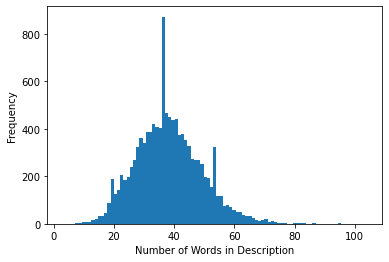

In [4]:
#add a column for the word count
df['word_count'] = df['description'].apply(lambda x: len(str(x).split(" ")))

print("Word Count Median: " + str(df['word_count'].median()))
print(df['word_count'].describe())

x = df['word_count']

n_bins = 95
plt.hist(x, bins=n_bins)
plt.xlabel('Number of Words in Description')
plt.ylabel('Frequency')
plt.show()

82.0
count    65.000000
mean     82.630769
std       1.790332
min      80.000000
25%      82.000000
50%      82.000000
75%      84.000000
max      89.000000
Name: points, dtype: float64


Text(0.5, 1.0, 'Points Counts')

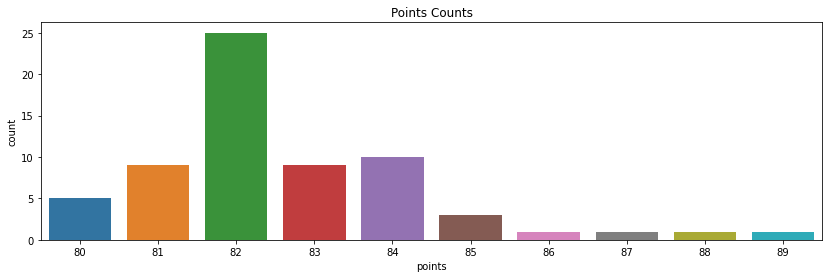

In [5]:
#word counts less than 15
wc15 = df.loc[df['word_count'] < 15]

print(wc15.points.median())
print(wc15.points.describe())

#plot the counts
plt.figure(figsize=(14,4))
sns.countplot(x ='points', data = wc15).set_title("Points Counts")

93.0
count    60.000000
mean     92.600000
std       2.532501
min      85.000000
25%      91.000000
50%      93.000000
75%      94.000000
max      98.000000
Name: points, dtype: float64


Text(0.5, 1.0, 'Points Counts')

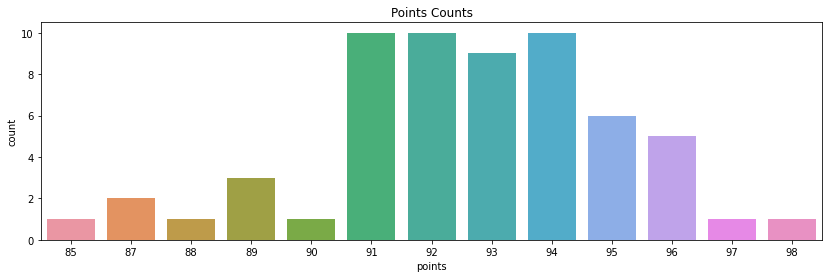

In [6]:
#word counts greater than 70
wc70 = df.loc[df['word_count'] > 70]

print(wc70.points.median())
print(wc70.points.describe())

#plot the counts
plt.figure(figsize=(14,4))
sns.countplot(x ='points', data = wc70).set_title("Points Counts")

Number of Unique Points: 21
Points Median: 88.0
count    11753.000000
mean        88.340083
std          3.231557
min         80.000000
25%         86.000000
50%         88.000000
75%         91.000000
max        100.000000
Name: points, dtype: float64


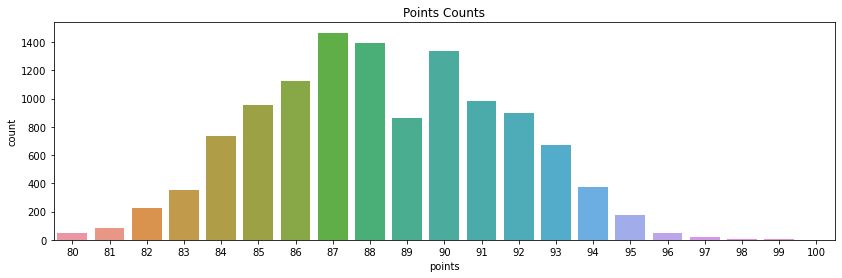

In [7]:
print("Number of Unique Points: " + str(len(df['points'].unique())))
print("Points Median: " + str(df['points'].median()))
print(df['points'].describe())

plt.figure(figsize=(14,4))

sns.countplot(x='points', data=df).set_title("Points Counts")
plt.show()

#add column to flag records with rating greater than 88
df['above_avg'] = [1 if points > 88 else 0 for points in df['points']]

In [9]:
# nltk.download('wordnet')

#create a list of stop words
stop_words = set(stopwords.words("english"))

#show how many words are in the list of stop words
print(len(stop_words))
#179

#construct a new list to store the cleaned text
clean_desc = []
for w in range(0,len(df.description)):
    desc = df['description'][w].lower()
    
    #remove punctuation
    desc = re.sub('[^a-zA-Z]', ' ', desc)
    
    #remove tags
    desc = re.sub("&lt;/?.*?&gt;"," &lt;&gt; ",desc)
    
    #remove special characters and digits
    desc = re.sub("(\\d|\\W)+"," ",desc)
    
    split_text = desc.split()
    
    #Lemmatisation
    lem = WordNetLemmatizer()
    split_text = [lem.lemmatize(word) for word in split_text if not word in stop_words and len(word) >2] 
    split_text = " ".join(split_text)
    clean_desc.append(split_text)

179


In [10]:
#TF-IDF vectorizer
tfv = TfidfVectorizer(stop_words = stop_words, ngram_range = (1,1))

#transform
vec_text = tfv.fit_transform(clean_desc)

#returns a list of words.
words = tfv.get_feature_names()

In [11]:
tfv

TfidfVectorizer(stop_words={'a', 'about', 'above', 'after', 'again', 'against',
                            'ain', 'all', 'am', 'an', 'and', 'any', 'are',
                            'aren', "aren't", 'as', 'at', 'be', 'because',
                            'been', 'before', 'being', 'below', 'between',
                            'both', 'but', 'by', 'can', 'couldn', "couldn't", ...})

In [20]:
#setup kmeans clustering
kmeans = KMeans(n_clusters = 21, n_init = 17, n_jobs = -1, tol = 0.01, max_iter = 200)

#fit the data 
kmeans.fit(vec_text)

#this loop transforms the numbers back into words
common_words = kmeans.cluster_centers_.argsort()[:,-1:-11:-1]
for num, centroid in enumerate(common_words):
    print(str(num) + ' : ' + ', '.join(words[word] for word in centroid))

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:792: FutureWarning: 'n_jobs' was deprecated in version 0.23 and will be removed in 1.0 (renaming of 0.25).
  warnings.warn("'n_jobs' was deprecated in version 0.23 and will be"


0 : dry, chardonnay, flavor, oak, acidity, pineapple, fruit, lime, tropical, rich
1 : fruity, ready, drink, wine, attractive, crisp, soft, acidity, light, fresh
2 : year, age, wine, fruit, acidity, structure, ripe, rich, flavor, least
3 : style, made, popular, buttered, pineapple, modern, toast, jam, flavor, vanilla
4 : sweet, pineapple, simple, flavor, vanilla, orange, like, taste, chardonnay, apricot
5 : wine, oak, vineyard, apple, lemon, finish, caramel, site, pear, acidity
6 : full, bodied, wine, flavor, apple, finish, rich, pear, oak, texture
7 : nose, lemon, bottling, palate, lime, show, apple, salt, aroma, sea
8 : aroma, finish, melon, flavor, feel, apple, palate, fruit, tropical, banana
9 : ripe, wine, fruit, drink, acidity, yellow, rich, full, rounded, texture
10 : palate, note, apple, finish, lemon, toasted, aroma, chardonnay, citrus, hint
11 : buttered, toast, pineapple, flavor, chardonnay, vanilla, oak, acidity, orange, rich
12 : wood, wine, fruit, aging, ripe, drink, rich,

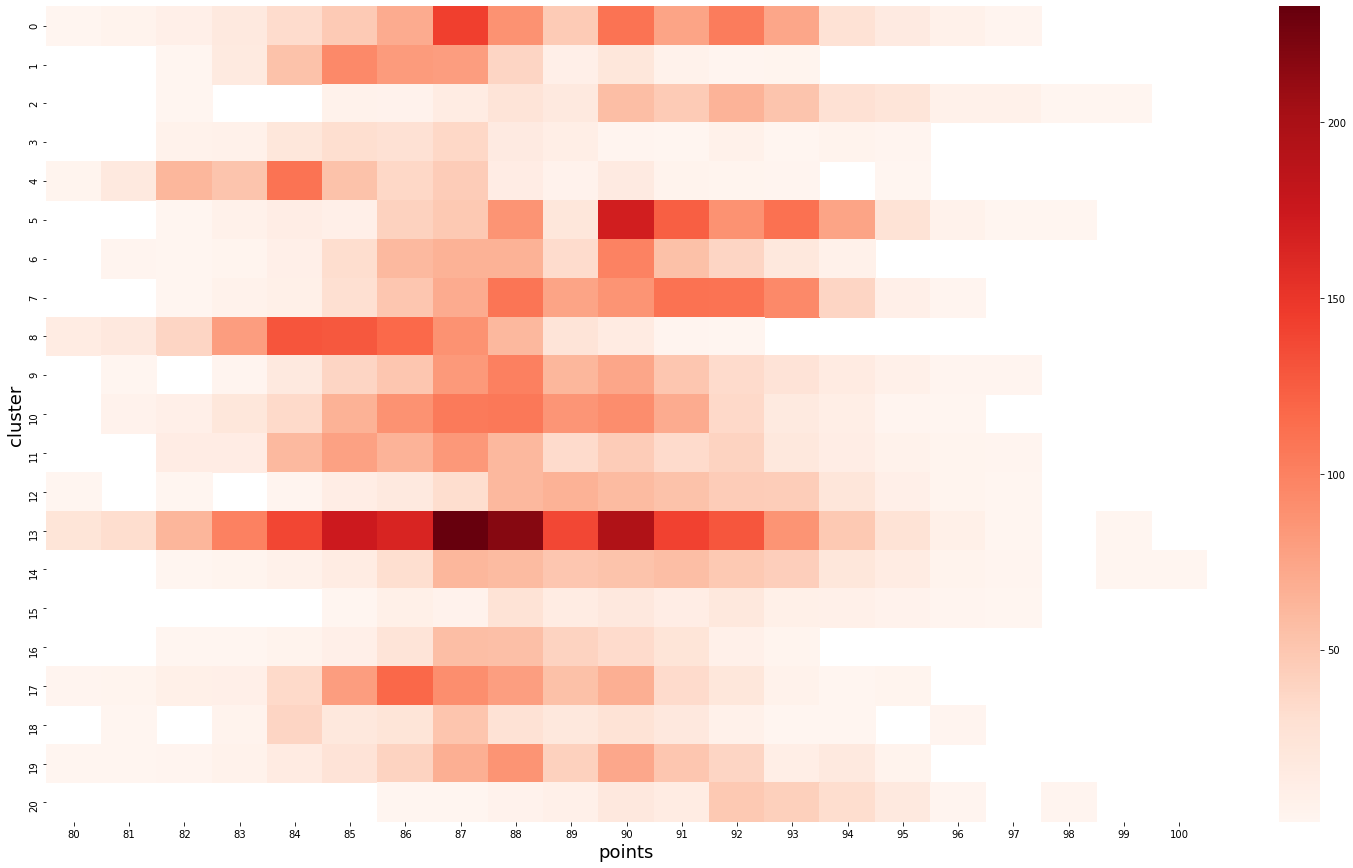

In [21]:
#add the cluster label to the data frame
df['cluster'] = kmeans.labels_

clusters = df.groupby(['cluster', 'points']).size()

fig, ax1 = plt.subplots(figsize = (26, 15))
sns.heatmap(clusters.unstack(level = 'points'), ax = ax1, cmap = 'Reds')

ax1.set_xlabel('points').set_size(18)
ax1.set_ylabel('cluster').set_size(18)

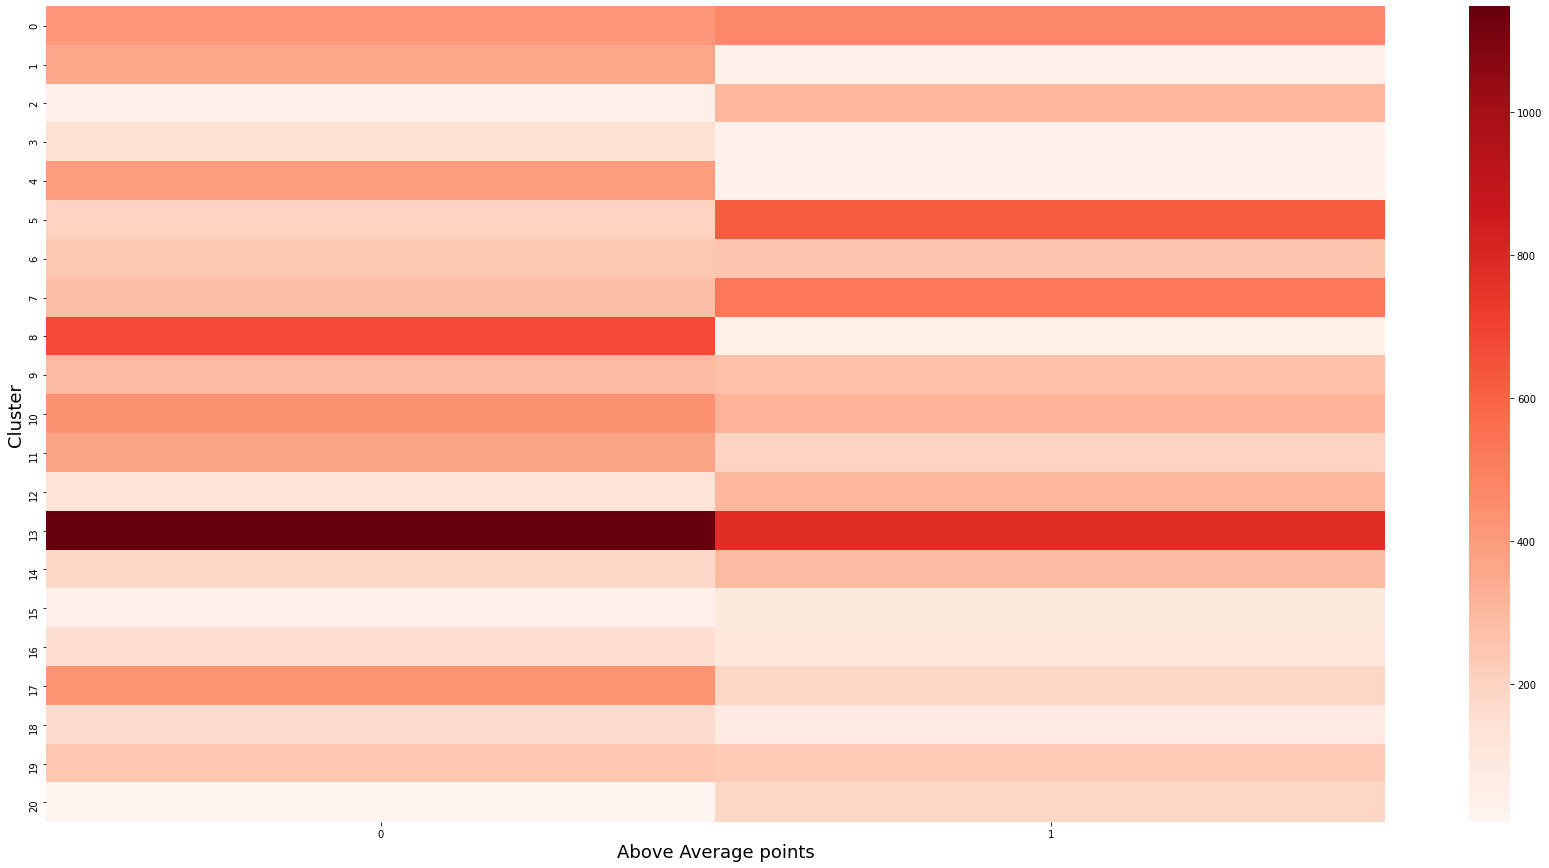

In [22]:
clusters = df.groupby(['cluster', 'above_avg']).size()

fig2, ax2 = plt.subplots(figsize = (30, 15))
sns.heatmap(clusters.unstack(level = 'above_avg'), ax = ax2, cmap="Reds")

ax2.set_xlabel('Above Average points').set_size(18)
ax2.set_ylabel('Cluster').set_size(18)

In [23]:
#create dataframe of reviews not above average
not_above = df.loc[df['above_avg'] == 0]
not_above.describe()

#create data frame of reviews above average
above_avg = df.loc[df['above_avg'] == 1]
above_avg.describe()

,index,points,price,word_count,above_avg,cluster
count,5377.000000,5377.000000,5022.000000,5377.000000,5377.0,5377.000000
mean,65844.851218,91.265762,49.592792,43.834108,1.0,9.519993
std,37260.545808,1.754948,57.901654,10.069624,0.0,5.573209
min,121.000000,89.000000,8.000000,14.000000,1.0,0.000000
25%,34588.000000,90.000000,28.000000,37.000000,1.0,5.000000
50%,65633.000000,91.000000,39.000000,43.000000,1.0,10.000000
75%,97732.000000,92.000000,54.750000,50.000000,1.0,13.000000
max,129955.000000,100.000000,2013.000000,104.000000,1.0,20.000000


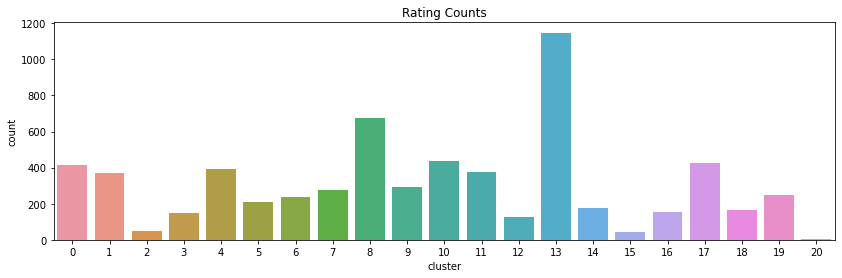

In [24]:
#plot the counts
plt.figure(figsize=(14,4))
sns.countplot(x='cluster', data=not_above).set_title("Rating Counts")
plt.show()

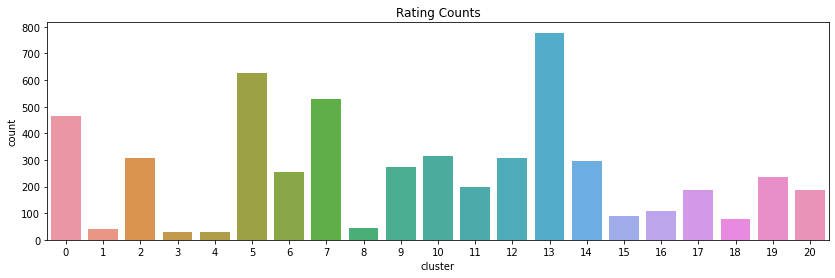

In [25]:
plt.figure(figsize=(14,4))
sns.countplot(x='cluster', data=above_avg).set_title("Rating Counts")
plt.show()